# CREATE FIGURE 4B-F
## last updated: 08.01.25
#### This code also runs the Fisher's exact test for the CCND1/IC-gene co-amplification relationship described in the text (see final paragraph of "Intra-IC-subtype gene overlap drives ecDNA sequence conservation".

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact
import ast
from collections import Counter

### Figure 4B

In [2]:
# figure 4b compares the variability of gene overlap across samples and across IC subtypes

In [3]:
# load path to cycle-level data table with confidence assignment included
cycle_level_data_table = 'full_tool_testing/ic_intrasample_filt_cycle_data_w_conf.csv'
cohort_df = pd.read_csv(cycle_level_data_table)

In [4]:
cohort_df["Cycle Regions List"] = cohort_df["Cycle Regions List"].apply(ast.literal_eval)
cohort_df["Cycle Genes List"] = cohort_df["Cycle Genes List"].apply(ast.literal_eval)
cohort_df["Cycle Genes List"] = cohort_df["Cycle Genes List"].apply(lambda x: list(set(x)))

In [5]:
# get subset of high confidence cycles
cohort_HC_df = cohort_df[cohort_df["Confidence"] == "high"]

In [6]:
# load file with information about IC subtype of samples
subtype_info = 'full_tool_testing/BCarc_eniclust.csv'
subtype_df = pd.read_csv(subtype_info)
subtype_df = subtype_df[["Sample", "ENiClust", "ER"]]

In [7]:
cohort_ic_df = pd.merge(cohort_df, subtype_df, on="Sample", how="left")

In [13]:
# get subset of high confidence cycles with IC information
cohort_ic_HC_df = cohort_ic_df[cohort_ic_df["Confidence"] == "high"]

In [14]:
# load path to cycle-level Jaccard index calculations
all_jaccs = 'full_tool_testing/ic_intrasample_filt_jacc_data.csv'
all_jaccs_df = pd.read_csv(all_jaccs)

In [15]:
all_ic_jaccs_df = all_jaccs_df.merge(subtype_df, left_on="Sample1", right_on="Sample", how="left").rename(columns={"ENiClust": "Sample1 eniclust"}).drop(columns=["Sample"])

all_ic_jaccs_df = all_ic_jaccs_df.merge(subtype_df, left_on="Sample2", right_on="Sample", how="left").rename(columns={"ENiClust": "Sample2 eniclust"}).drop(columns=["Sample"])

In [16]:
# get all Jaccard indices between unique sample pairs
inter_sample_jaccs_df = all_ic_jaccs_df[all_ic_jaccs_df["Sample1"] != all_ic_jaccs_df["Sample2"]]

In [17]:
all_ic_jaccs_df_reshaped = pd.concat([
    inter_sample_jaccs_df[['Sample1', 'Amp1', 'Cycle1', 'BP Jaccard', 'Gene Jaccard', 'Breakend Jaccard', 'Overlapping Genes', 'Overlapping Breakends', "Sample1 eniclust"]].rename(columns={'Sample1': 'Sample', 'Amp1': 'Amplicon', 'Cycle1': 'Cycle', "Sample1 eniclust": "Eniclust"}),
    inter_sample_jaccs_df[['Sample2', 'Amp2', 'Cycle2', 'BP Jaccard', 'Gene Jaccard', 'Breakend Jaccard', 'Overlapping Genes', 'Overlapping Breakends', "Sample2 eniclust"]].rename(columns={'Sample2': 'Sample', 'Amp2': 'Amplicon', 'Cycle2': 'Cycle', "Sample2 eniclust": "Eniclust"})
])

all_ic_max_gene_jaccs_df = all_ic_jaccs_df_reshaped.groupby(['Sample', 'Amplicon', 'Cycle'])['Gene Jaccard'].max().reset_index()
all_ic_max_gene_jaccs_df = pd.merge(all_ic_max_gene_jaccs_df, subtype_df, on="Sample", how="left").rename(columns={"Gene Jaccard": "Max Gene Jaccard"})
HC_all_ic_max_gene_jaccs_df = pd.merge(cohort_HC_df, all_ic_max_gene_jaccs_df, on=["Sample", "Amplicon", "Cycle"], how="left").rename(columns={'ENiClust': 'Eniclust'})[["Sample", "Amplicon", "Cycle", "Max Gene Jaccard", "Eniclust"]]

In [18]:
intra_ic_SSE_jaccs_df = inter_sample_jaccs_df[inter_sample_jaccs_df["Sample1 eniclust"] == inter_sample_jaccs_df["Sample2 eniclust"]]

In [19]:
intra_ic_SSE_jaccs_df_reshaped = pd.concat([
    intra_ic_SSE_jaccs_df[['Sample1', 'Amp1', 'Cycle1', 'BP Jaccard', 'Gene Jaccard', 'Breakend Jaccard', 'Overlapping Genes', 'Overlapping Breakends', "Sample1 eniclust"]].rename(columns={'Sample1': 'Sample', 'Amp1': 'Amplicon', 'Cycle1': 'Cycle', "Sample1 eniclust": "Eniclust"}),
    intra_ic_SSE_jaccs_df[['Sample2', 'Amp2', 'Cycle2', 'BP Jaccard', 'Gene Jaccard', 'Breakend Jaccard', 'Overlapping Genes', 'Overlapping Breakends', "Sample2 eniclust"]].rename(columns={'Sample2': 'Sample', 'Amp2': 'Amplicon', 'Cycle2': 'Cycle', "Sample2 eniclust": "Eniclust"})
])

intra_ic_SSE_max_gene_jaccs_df = intra_ic_SSE_jaccs_df_reshaped.groupby(['Sample', 'Amplicon', 'Cycle'])['Gene Jaccard'].max().reset_index()
intra_ic_SSE_max_gene_jaccs_df = pd.merge(intra_ic_SSE_max_gene_jaccs_df, subtype_df, on="Sample", how="left").rename(columns={"Gene Jaccard": "Max Gene Jaccard"})
HC_intra_ic_SSE_max_gene_jaccs_df = pd.merge(cohort_HC_df, intra_ic_SSE_max_gene_jaccs_df, on=["Sample", "Amplicon", "Cycle"], how="left").rename(columns={'ENiClust': 'Eniclust'})[["Sample", "Amplicon", "Cycle", "Max Gene Jaccard", "Eniclust"]]

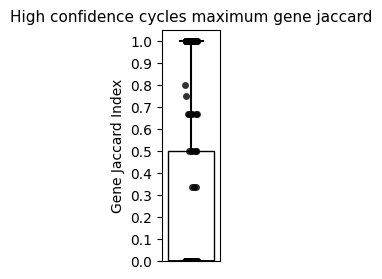

In [21]:
plt.figure(figsize=(0.75, 3))

sns.boxplot(y='Max Gene Jaccard', data=HC_all_ic_max_gene_jaccs_df, whis=1.5,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(markerfacecolor='white', marker='o', markersize=0))

sns.stripplot(y='Max Gene Jaccard', data=HC_all_ic_max_gene_jaccs_df, color='black', alpha=0.8, jitter=True)

plt.ylim(0, 1.05)
plt.yticks([i/10 for i in range(0, 11)])
plt.xticks([])

plt.xlabel("")
plt.ylabel("Gene Jaccard Index")

plt.title('High confidence cycles maximum gene jaccard', fontsize=11)

plt.show()

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_72570/1457630079.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_72570/1457630079.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels, rotation=0, ha='center')


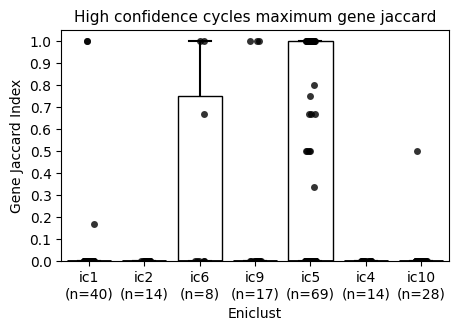

In [22]:
ic_order = ["ic1", "ic2", "ic6", "ic9", "ic5", "ic4", "ic10"]
group_counts = HC_intra_ic_SSE_max_gene_jaccs_df['Eniclust'].value_counts().reindex(ic_order).fillna(0).astype(int)

plt.figure(figsize=(5, 3))

sns.boxplot(
    x='Eniclust', y='Max Gene Jaccard', data=HC_intra_ic_SSE_max_gene_jaccs_df, palette="Set3", whis=1.5,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(markerfacecolor='white', marker='o', markersize=0),
    order=ic_order
)

sns.stripplot(
    x='Eniclust', y='Max Gene Jaccard', data=HC_intra_ic_SSE_max_gene_jaccs_df, color='black', alpha=0.8, jitter=True, order=ic_order
)

new_labels = [f"{group}\n(n={count})" for group, count in zip(ic_order, group_counts)]
plt.gca().set_xticklabels(new_labels, rotation=0, ha='center')

plt.ylim(0, 1.05)
plt.yticks([i / 10 for i in range(0, 11)])
plt.xlabel("Eniclust")
plt.ylabel("Gene Jaccard Index")
plt.title('High confidence cycles maximum gene jaccard', fontsize=11)

plt.show()

In [23]:
# Perform Kruskal-Wallis test
kruskal_stat, kruskal_p = kruskal(
    *[HC_intra_ic_SSE_max_gene_jaccs_df[HC_intra_ic_SSE_max_gene_jaccs_df['Eniclust'] == group]['Max Gene Jaccard'] for group in ic_order]
)

k = len(ic_order)  # Number of groups
N = len(HC_intra_ic_SSE_max_gene_jaccs_df)  # Total sample size
eta_squared = (kruskal_stat - k + 1) / (N - k)

print(f"p = {kruskal_p}")
print(f"eta squared = {eta_squared}")

p = 1.1125148690509318e-07
eta squared = 0.15269079057351262


In [24]:
# Peform Dunn tests
HC_intra_ic_SSE_max_gene_jaccs_df_NO_NA_IC = HC_intra_ic_SSE_max_gene_jaccs_df.dropna(subset=['Max Gene Jaccard', 'Eniclust'])
dunn_results = sp.posthoc_dunn(
    HC_intra_ic_SSE_max_gene_jaccs_df_NO_NA_IC, val_col='Max Gene Jaccard', group_col='Eniclust', p_adjust='bonferroni'
)
print(dunn_results)

             ic1      ic10       ic2   ic3/ic7       ic4       ic5  ic6  ic8  \
ic1      1.00000  1.000000  1.000000  1.000000  1.000000  0.000070  1.0  1.0   
ic10     1.00000  1.000000  1.000000  1.000000  1.000000  0.000099  1.0  1.0   
ic2      1.00000  1.000000  1.000000  1.000000  1.000000  0.004628  1.0  1.0   
ic3/ic7  1.00000  1.000000  1.000000  1.000000  1.000000  0.059128  1.0  1.0   
ic4      1.00000  1.000000  1.000000  1.000000  1.000000  0.004628  1.0  1.0   
ic5      0.00007  0.000099  0.004628  0.059128  0.004628  1.000000  1.0  1.0   
ic6      1.00000  1.000000  1.000000  1.000000  1.000000  1.000000  1.0  1.0   
ic8      1.00000  1.000000  1.000000  1.000000  1.000000  1.000000  1.0  1.0   
ic9      1.00000  1.000000  1.000000  1.000000  1.000000  0.491789  1.0  1.0   

              ic9  
ic1      1.000000  
ic10     1.000000  
ic2      1.000000  
ic3/ic7  1.000000  
ic4      1.000000  
ic5      0.491789  
ic6      1.000000  
ic8      1.000000  
ic9      1.000000  

### Figure 4C

In [29]:
# figure 4c compares the proportion of zero vs non-zero gene overlap across samples and across IC subtypes

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_72570/3774920040.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


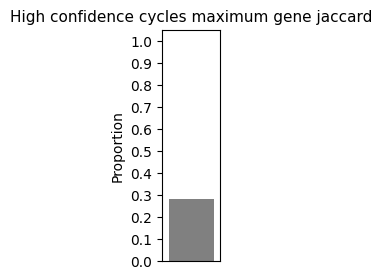

In [25]:
counts = pd.Series({
    'Zero': (HC_all_ic_max_gene_jaccs_df['Max Gene Jaccard'] == 0).sum(),
    'Non-zero': (HC_all_ic_max_gene_jaccs_df['Max Gene Jaccard'] != 0).sum()
})

proportions = counts / counts.sum()

fig, ax = plt.subplots(figsize=(0.75, 3))

ax.bar(
    x=0, width=0.6, 
    bottom=0, color='grey', label='Non-zero', height=proportions['Non-zero']
)
ax.bar(
    x=0, width=0.7, 
    bottom=proportions['Non-zero'], color='white', label='Non-zero', height=proportions['Zero']
)

plt.xlabel("Eniclust")
plt.ylabel("Proportion")
plt.title("High confidence cycles maximum gene jaccard", fontsize=11)
plt.yticks([i / 10 for i in range(0, 11)])

ax.set_xticks([])
ax.set_xlabel("")

# Show the plot
plt.tight_layout()
plt.show()

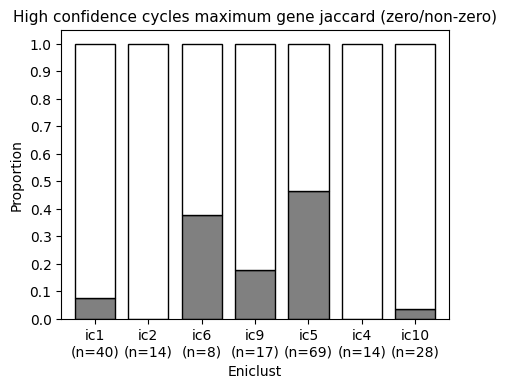

In [26]:
group_counts = HC_intra_ic_SSE_max_gene_jaccs_df['Eniclust'].value_counts().reindex(ic_order).fillna(0).astype(int)
proportions = HC_intra_ic_SSE_max_gene_jaccs_df.groupby('Eniclust')['Max Gene Jaccard'] \
    .apply(lambda x: pd.Series({'Zero': (x == 0).sum(), 'Non-zero': (x != 0).sum()})) \
    .unstack()

proportions_normalized = proportions.div(proportions.sum(axis=1), axis=0)
proportions_normalized = proportions_normalized[['Non-zero', 'Zero']]
proportions_normalized = proportions_normalized.loc[ic_order]

ax = proportions_normalized.plot(
    kind='bar', stacked=True, figsize=(5, 3.75), 
    color=['grey', 'white'],  
    edgecolor='black', width=0.75
)

plt.xlabel("Eniclust")
plt.ylabel("Proportion")
plt.title("High confidence cycles maximum gene jaccard (zero/non-zero)", fontsize=11)
plt.xticks(rotation=0)
plt.yticks([i / 10 for i in range(0, 11)])

new_labels = [f"{group}\n(n={count})" for group, count in zip(ic_order, group_counts)]
ax.set_xticklabels(new_labels)
ax.get_legend().remove()

plt.show()

In [27]:
# Perform Chi-squared test
contingency_table = proportions.values
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared test p-value: {p_val}")

Chi-squared test p-value: 2.802831283483507e-07


### Figure 4D

In [28]:
# figure 4d displays the proportion of cycles from each IC subtype with gene co-amplifications

In [30]:
# function to add additional IC-specific genes to the cycle genes lists
def update_cycle_genes_list(row, gene_name, gene_chromosome, gene_start, gene_end):
    # Iterate through the regions in the "Cycle Regions List"
    for region in row['Cycle Regions List']:
        region_chromosome, region_start, region_end = region
        
        # Check if the gene is completely contained by the region
        if gene_chromosome == region_chromosome and region_start <= gene_start and region_end >= gene_end:
            # Gene is contained, update the "Cycle Genes List" by appending the gene name
            if gene_name not in row['Cycle Genes List']:
                row['Cycle Genes List'].append(gene_name)
            break  # No need to check other regions once the gene is found
            
    return row['Cycle Genes List']

In [31]:
gene_name = "RPS6KB1"
gene_chromosome = '17'
gene_start = 57970482
gene_end = 58027935

cohort_ic_HC_df['Cycle Genes List'] = cohort_ic_HC_df.apply(
    lambda row: update_cycle_genes_list(row, gene_name, gene_chromosome, gene_start, gene_end), axis=1
)

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_72570/2415985930.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cohort_ic_HC_df['Cycle Genes List'] = cohort_ic_HC_df.apply(


In [32]:
gene_name = "ZNF703"
gene_chromosome = "8"
gene_start = 37553300
gene_end = 37557537

cohort_ic_HC_df['Cycle Genes List'] = cohort_ic_HC_df.apply(
    lambda row: update_cycle_genes_list(row, gene_name, gene_chromosome, gene_start, gene_end), axis=1
)

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_72570/3291862100.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cohort_ic_HC_df['Cycle Genes List'] = cohort_ic_HC_df.apply(


In [33]:
cohort_ic_HC_df["Co-amp"] = cohort_ic_HC_df["Cycle Genes List"].apply(lambda x: len(x) > 1)

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_72570/3180173289.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cohort_ic_HC_df["Co-amp"] = cohort_ic_HC_df["Cycle Genes List"].apply(lambda x: len(x) > 1)


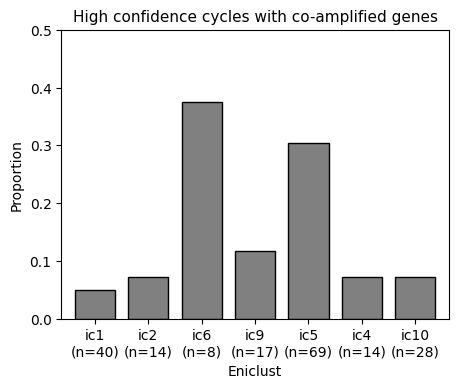

In [34]:
group_counts = cohort_ic_HC_df['ENiClust'].value_counts().reindex(ic_order).fillna(0).astype(int)

proportions = cohort_ic_HC_df.groupby('ENiClust')['Co-amp'].value_counts(normalize=True).unstack()
proportions = proportions.loc[:, [False, True]]
proportions = proportions.loc[ic_order]

ax1 = proportions.plot(
    kind='bar', stacked=True, figsize=(5, 3.75), 
    color=['grey', 'white'],  
    edgecolor='black', width=0.75
)

plt.xlabel("Eniclust")
plt.ylabel("Proportion")
plt.title("High confidence cycles with co-amplified genes", fontsize=11)
plt.xticks(rotation=0)
plt.ylim(0, 0.5)
plt.yticks([i / 10 for i in range(0, 6)])

new_labels = [f"{group}\n(n={count})" for group, count in zip(ic_order, group_counts)]
ax1.set_xticklabels(new_labels)
ax1.get_legend().remove()

plt.show()

### Figure 4E
#### figure 4e is handmade based on the following counts, showing the count of unique gene co-amplifications for each gene on high confidence cycles, separated by IC subtype and colored by interactions with IC-specific genes.

In [35]:
eniclust_gene_sets = {"ic5": ["ERBB2"], "ic1": ["RPS6KB1"], "ic2": ["CCND1"], "ic6": ["FGFR1", "ZNF703"], "ic9": ["MYC", "RAD21"]}

In [36]:
cohort_ic_MC_df = cohort_ic_df[cohort_ic_df["Confidence"] == "medium"]

In [37]:
ic_gene_dicts = {}

for _, row in cohort_ic_HC_df.iterrows():

    ic = row["ENiClust"]
    if ic not in ic_gene_dicts:
        ic_gene_dicts[ic] = {}

    cycle_genes_list = row["Cycle Genes List"]

    for gene in cycle_genes_list:
        if gene not in ic_gene_dicts[ic]:
            ic_gene_dicts[ic][gene] = []
        for other_gene in cycle_genes_list:
            if other_gene != gene and other_gene not in ic_gene_dicts[ic][gene]:
                ic_gene_dicts[ic][gene].append(other_gene)

In [39]:
# we print this for each subtype, and use the information to construct figure 4E
# keys are each gene found in a cycle from that subtype, values are lists of the unique genes they are found co-amplified with in cycles
ic_gene_dicts['ic5']

{'ERBB2': ['CDK12', 'IKZF3', 'MLLT6', 'LASP1', 'RPS6KB1'],
 'CDK12': ['ERBB2', 'MLLT6', 'LASP1', 'IKZF3'],
 'MLLT6': ['LASP1', 'CDK12', 'ERBB2'],
 'LASP1': ['MLLT6', 'CDK12', 'ERBB2'],
 'CCND1': [],
 'PPM1D': ['CLTC', 'RPS6KB1'],
 'CLTC': ['PPM1D', 'RPS6KB1', 'HLF'],
 'RPS6KB1': ['PPM1D', 'CLTC', 'HLF', 'ERBB2', 'IKZF3'],
 'IKZF3': ['ERBB2', 'CDK12', 'FGFR1', 'RPS6KB1'],
 'FGFR1': ['IKZF3'],
 'H3F3B': ['HLF'],
 'HLF': ['H3F3B', 'CLTC', 'RPS6KB1'],
 'MYC': ['RAD21', 'EXT1'],
 'RAD21': ['MYC', 'EXT1'],
 'SPOP': ['COL1A1', 'KAT7'],
 'COL1A1': ['SPOP', 'KAT7'],
 'KAT7': ['SPOP', 'COL1A1'],
 'EXT1': ['MYC', 'RAD21'],
 'CCDC6': [],
 'FADD': []}

### Figure 4F

In [40]:
# figure 4f displays the unique co-amplified gene pair counts in high confidence cycles for IC5, IC6, and IC1 samples

In [41]:
# note the co-amplification pairs for each eniclust
co_amplified_pairs = {}

for _, row in cohort_ic_HC_df.iterrows():
    genes = row['Cycle Genes List']  # This is the column with the list of genes in the cycle
    eniclust = row["ENiClust"]
    if eniclust not in co_amplified_pairs:
        co_amplified_pairs[eniclust] = []
    for i in range(len(genes)):
        for j in range(i + 1, len(genes)):
            if genes[i] != genes[j]:
                co_amplified_pairs[eniclust].append((genes[i], genes[j]))

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_72570/357837889.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Co-amplified Gene', y='Count', data=barplot_df, orient='v', ci=None, color='black')


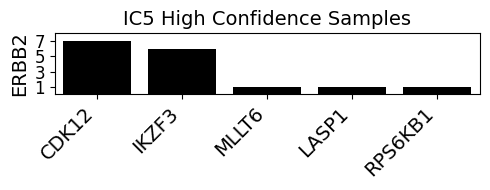

In [42]:
base_gene = "ERBB2"
subtype = "ic5"

gene_subtype_coamps = []

for gene1, gene2 in co_amplified_pairs[subtype]:
    if gene1 == base_gene:
        gene_subtype_coamps.append(gene2)
    elif gene2 == base_gene:
        gene_subtype_coamps.append(gene1)

# count of cycles co-amplified with each gene
gene_counts = Counter(gene_subtype_coamps)

barplot_data = [{'Co-amplified Gene': gene, 'Count': count} for gene, count in gene_counts.items()]
barplot_df = pd.DataFrame(barplot_data)

barplot_df = barplot_df.sort_values(by='Count', ascending=False)

plt.figure(figsize=(5, 2))

sns.barplot(x='Co-amplified Gene', y='Count', data=barplot_df, orient='v', ci=None, color='black')
plt.title('IC5 High Confidence Samples', fontsize=14)
plt.xlabel('', fontsize=14)
plt.ylabel(base_gene, fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=14)  # Rotate x-axis labels
plt.yticks(range(1, 9, 2), fontsize=12)
plt.ylim(0, 8)
plt.tight_layout()
plt.grid(False)
plt.show()

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_72570/3373134936.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Co-amplified Gene', y='Count', data=barplot_df, orient='v', ci=None, color='black')


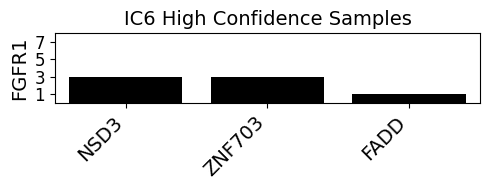

In [43]:
base_gene = "FGFR1"
subtype = "ic6"

gene_subtype_coamps = []

for gene1, gene2 in co_amplified_pairs[subtype]:
    if gene1 == base_gene:
        gene_subtype_coamps.append(gene2)
    elif gene2 == base_gene:
        gene_subtype_coamps.append(gene1)

# count of cycles co-amplified with each gene
gene_counts = Counter(gene_subtype_coamps)

barplot_data = [{'Co-amplified Gene': gene, 'Count': count} for gene, count in gene_counts.items()]
barplot_df = pd.DataFrame(barplot_data)

barplot_df = barplot_df.sort_values(by='Count', ascending=False)

plt.figure(figsize=(5, 2))

sns.barplot(x='Co-amplified Gene', y='Count', data=barplot_df, orient='v', ci=None, color='black')
plt.title('IC6 High Confidence Samples', fontsize=14)
plt.xlabel('', fontsize=14)
plt.ylabel(base_gene, fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=14)  # Rotate x-axis labels
plt.yticks(range(1, 9, 2), fontsize=12)
plt.ylim(0, 8)
plt.tight_layout()
plt.grid(False)
plt.show()

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_72570/2441706908.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Co-amplified Gene', y='Count', data=barplot_df, orient='v', ci=None, color='black')


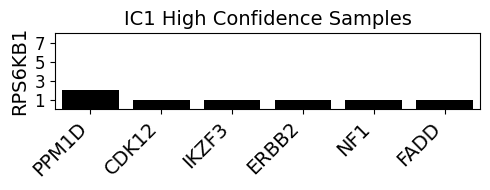

In [44]:
base_gene = "RPS6KB1"
subtype = "ic1"

gene_subtype_coamps = []

for gene1, gene2 in co_amplified_pairs[subtype]:
    if gene1 == base_gene:
        gene_subtype_coamps.append(gene2)
    elif gene2 == base_gene:
        gene_subtype_coamps.append(gene1)

# count of cycles co-amplified with each gene
gene_counts = Counter(gene_subtype_coamps)

barplot_data = [{'Co-amplified Gene': gene, 'Count': count} for gene, count in gene_counts.items()]
barplot_df = pd.DataFrame(barplot_data)

barplot_df = barplot_df.sort_values(by='Count', ascending=False)

plt.figure(figsize=(5, 2))

sns.barplot(x='Co-amplified Gene', y='Count', data=barplot_df, orient='v', ci=None, color='black')
plt.title('IC1 High Confidence Samples', fontsize=14)
plt.xlabel('', fontsize=14)
plt.ylabel(base_gene, fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=14)  # Rotate x-axis labels
plt.yticks(range(1, 9, 2), fontsize=12)
plt.ylim(0, 8)
plt.tight_layout()
plt.grid(False)
plt.show()

### CCND1 Fisher's Exact Test - in text

In [11]:
gene_column = 'Cycle Genes List'
target_gene = 'CCND1'

ic_oncogenes = ["ERBB2", "RPS6KB1", "CCND1", "FGFR1", "ZNF703", "MYC", "RAD21"]

def classify_row(gene_list):
    ic_onco_gene_set = set(gene_list) & set(ic_oncogenes)  # intersection with IC oncogenes
    CCND1_cycle = target_gene in gene_list
    ic_onco_cycle = len(ic_onco_gene_set) > 0
    co_amp = len(gene_list) > 1  # more than 1 gene
    return CCND1_cycle, ic_onco_cycle, co_amp

cohort_HC_df[['has_CCND1', 'has_ic_onco', 'is_coamp']] = cohort_HC_df[gene_column].apply(lambda genes: pd.Series(classify_row(genes)))

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_72570/2515066181.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cohort_HC_df[['has_CCND1', 'has_ic_onco', 'is_coamp']] = cohort_HC_df[gene_column].apply(lambda genes: pd.Series(classify_row(genes)))


In [12]:
ccnd1 = cohort_HC_df[cohort_HC_df['has_CCND1'] == True]
others = cohort_HC_df[(cohort_HC_df['has_CCND1'] == False) & (cohort_HC_df['has_ic_onco'] == True)]

# Counts
a = sum(ccnd1['is_coamp'])
b = sum(~ccnd1['is_coamp'])
c = sum(others['is_coamp'])
d = sum(~others['is_coamp'])

# Fisher's Exact Test
oddsratio, pvalue = fisher_exact([[a, b], [c, d]], alternative='less')  # 'less' = less likely to be co-amp
print(f"Fisher's Exact Test (CCND1 vs other IC-specific oncogenes):")
print(f"Contingency Table:\n[[{a}, {b}],\n [{c}, {d}]]")
print(f"Odds Ratio: {oddsratio:.3f}, P-value: {pvalue:.4g}")

Fisher's Exact Test (CCND1 vs other IC-specific oncogenes):
Contingency Table:
[[1, 5],
 [24, 6]]
Odds Ratio: 0.050, P-value: 0.006167
